In [1]:
import os

import pandas as pd
import polars as pl
import itertools
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2'

In [3]:
# Load dataset
gene_pl = pl.read_parquet(os.path.join(DATASET_DIR, 'dataset', 'gene_w_label_value_1.parquet'))
gene_pl

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0


In [4]:
gene_pl['value_1'].describe()

statistic,value
str,f64
"""count""",22154.0
"""null_count""",0.0
"""mean""",21.856847
"""std""",167.605195
"""min""",0.0
"""25%""",0.0155566
"""50%""",1.14229
"""75%""",12.2663
"""max""",12870.9


In [5]:
gene_pl.filter(pl.col('value_1') == 0.0)

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000023""","[0.0, 0.0, … 0.0]",1,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",4,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000033""","[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",1,"[0.0, 0.0, … 0.0]",0,0.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0


In [6]:
marker_list = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']

gene_features = gene_pl.with_columns(
    pl.concat_list(marker_list).alias("combined_features")
)

In [7]:
gene_features

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,combined_features
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32,list[f64]
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[0.0, 0.0, … 0.0]"
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[0.0, 0.0, … 0.0]"
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0,"[0.0, 0.0, … 0.0]"
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1,"[0.0, 0.0, … 0.0]"
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1,"[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[0.0, 0.0, … 0.0]"
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[0.0, 0.0, … 0.0]"
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[0.0, 0.0, … 0.0]"


In [8]:
gene_features = gene_features.select(["gene_id", "combined_features", "value_1"])
gene_features

gene_id,combined_features,value_1
str,list[f64],f64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [9]:
sample_df = gene_features[:200]
sample_df

gene_id,combined_features,value_1
str,list[f64],f64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…
"""XLOC_000226""","[0.0, 0.0, … 0.0]",8.0957
"""XLOC_000227""","[0.0, 0.0, … 0.0]",6.90897
"""XLOC_000228""","[0.0, 0.0, … 0.0]",98.6757


In [10]:
sample_df.filter(pl.col('value_1') == 0.0)

gene_id,combined_features,value_1
str,list[f64],f64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000014""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000023""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000033""","[0.0, 0.0, … 0.0]",0.0
…,…,…
"""XLOC_000182""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000185""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000213""","[0.0, 0.0, … 0.0]",0.0


In [11]:
# Doing the permutation using cross join
permuted_df = sample_df.join(sample_df, how="cross")

In [12]:
permuted_df

gene_id,combined_features,value_1,gene_id_right,combined_features_right,value_1_right
str,list[f64],f64,str,list[f64],f64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…,…,…
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000226""","[0.0, 0.0, … 0.0]",8.0957
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000227""","[0.0, 0.0, … 0.0]",6.90897
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000228""","[0.0, 0.0, … 0.0]",98.6757


In [13]:
# Create the label
permuted_df = permuted_df.with_columns(
    pl.when(pl.col("value_1") > pl.col("value_1_right")).then(2)
      .when(pl.col("value_1") < pl.col("value_1_right")).then(0)
      .otherwise(1)
      .alias("label")
)

In [14]:
permuted_df

gene_id,combined_features,value_1,gene_id_right,combined_features_right,value_1_right,label
str,list[f64],f64,str,list[f64],f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,1
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0,1
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452,0
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743,0
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934,0
…,…,…,…,…,…,…
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000226""","[0.0, 0.0, … 0.0]",8.0957,0
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000227""","[0.0, 0.0, … 0.0]",6.90897,0
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000228""","[0.0, 0.0, … 0.0]",98.6757,0


In [15]:
permuted_df.group_by("label").len()

label,len
i32,u32
2,18772
1,2456
0,18772


In [16]:
# Combine features column into single column
permuted_df = permuted_df.with_columns(
    pl.concat_list("combined_features", "combined_features_right").alias("combined_features")
)

permuted_df

gene_id,combined_features,value_1,gene_id_right,combined_features_right,value_1_right,label
str,list[f64],f64,str,list[f64],f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,1
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0,1
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452,0
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743,0
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934,0
…,…,…,…,…,…,…
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000226""","[0.0, 0.0, … 0.0]",8.0957,0
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000227""","[0.0, 0.0, … 0.0]",6.90897,0
"""XLOC_000230""","[0.0, 0.0, … 0.0]",5.35409,"""XLOC_000228""","[0.0, 0.0, … 0.0]",98.6757,0


In [17]:
# Select X and y
X = permuted_df.select(pl.col('combined_features')).to_series().to_list()
y = permuted_df.select(pl.col('label')).to_series().to_list()

In [18]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

In [19]:
print(X.shape)
print(y.shape)

(40000, 40000)
(40000,)


In [20]:
class Classifier(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=3):
        super(Classifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Linear(hidden2_size, output_size)
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return torch.argmax(outputs, dim=1)

In [21]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    
    return device

In [22]:
def prepare_data(X, y):
    # Split the dataset into training, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [23]:
def create_data_loaders(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32, device=None):

    if device is None:
        device = get_device()
    
    X_train = torch.from_numpy(X_train).float().to(device)
    X_val = torch.from_numpy(X_val).float().to(device)
    X_test = torch.from_numpy(X_test).float().to(device)
    
    y_train = torch.from_numpy(y_train).long().to(device)
    y_val = torch.from_numpy(y_val).long().to(device)
    y_test = torch.from_numpy(y_test).long().to(device)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, val_loader, test_loader

In [24]:
def train_model(model, train_loader, val_loader, optimizer_type='adam', learning_rate=0.01, num_epochs=100, device=None):

    if device is None:
        device = get_device()
        
    # Output setup
    best_val_metric = float('-inf')
    best_model_path = 'ranking.pth'

    # For tracking train and validation
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_aucs, val_aucs = [], []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    model.to(device)
    
    # Choose optimizer
    if optimizer_type.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Optimizer must be 'sgd' or 'adam'")

     # Loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_true_labels = []
        train_predicted_probs = []

        for inputs, labels in train_loader:
            
            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
    
            train_true_labels.extend(labels.cpu().numpy())
            train_predicted_probs.extend(predicted.cpu().numpy())

        
        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        
        train_losses.append(round(avg_train_loss, 4))
        train_accuracies.append(round(train_accuracy, 2))

        # Validation phase
        model.eval()
        total_val_loss = 0
        correct_predictions = 0
        total_predictions = 0
        val_metric = 0
        val_true_labels = []
        val_predicted_probs = []
    
        with torch.no_grad():
            for inputs, labels in val_loader:
                # Forward pass
                outputs = model(inputs)
    
                # Compute validation loss
                val_loss = criterion(outputs, labels)
                total_val_loss += val_loss.item()
    
                # Compute accuracy
                _, predicted = torch.max(outputs, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()

                val_true_labels.extend(labels.cpu().numpy())
                val_predicted_probs.extend(predicted.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = 100 * correct_predictions / total_predictions
        val_metric = correct_predictions / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_probs, 
            average='macro',  # Use macro average for multi-class classification
            zero_division=0.0
        )

        # Save the best model
        if val_metric > best_val_metric:
            best_val_metric = val_metric
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved with validation metric: {best_val_metric:.4f}")
        
        val_true_labels = np.array(val_true_labels)
        val_predicted_probs = np.array(val_predicted_probs)
    
        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))
    
        # Print progress
        print(f'Epoch [{epoch+1}/{num_epochs}] - '
              f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}% - '
              f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
              f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
        )

        metrics = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies, 
            'val_accuracies': val_accuracies,
            'val_precisions': val_precisions,
            'val_recalls': val_recalls,
            'val_f1_scores': val_f1_scores
        }
    
    return model, metrics

In [25]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylim(0, 2)
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylim(0, 100)
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = 'training_vs_validation_ranking.png'
    plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'train', img_name))
    
    plt.show()

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(X, y)

In [27]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(13360, 40000)
(13320, 40000)
(13320, 40000)
(13360,)
(13320,)
(13320,)


In [28]:
train_loader, val_loader, test_loader = create_data_loaders(X_train, X_val, X_test, y_train, y_val, y_test)

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [29]:
model = Classifier(input_size=X_train.shape[1])

In [30]:
trained_model, metrics = train_model(model, train_loader, val_loader)

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB
New best model saved with validation metric: 23.9568
Epoch [1/100] - [TRAIN] Loss: 0.6433, Accuracy: 72.87% - [VAL] Loss: 0.5485, Accuracy: 75.00%, Precision: 0.69, Recall: 0.54, F1-Score: 0.53, 
New best model saved with validation metric: 24.9376
Epoch [2/100] - [TRAIN] Loss: 0.5013, Accuracy: 77.83% - [VAL] Loss: 0.5052, Accuracy: 78.07%, Precision: 0.73, Recall: 0.57, F1-Score: 0.57, 
New best model saved with validation metric: 25.0408
Epoch [3/100] - [TRAIN] Loss: 0.4674, Accuracy: 79.56% - [VAL] Loss: 0.4843, Accuracy: 78.39%, Precision: 0.53, Recall: 0.56, F1-Score: 0.54, 
New best model saved with validation metric: 25.3933
Epoch [4/100] - [TRAIN] Loss: 0.4575, Accuracy: 80.01% - [VAL] Loss: 0.4639, Accuracy: 79.50%, Precision: 0.54, Recall: 0.56, F1-Score: 0.55, 
Epoch [5/100] - [TRAIN] Loss: 0.4445, Accuracy: 80.77% - [VAL] Loss: 0.4577, Accuracy: 79.43%, Precision: 0.54, Recall: 0.56, F1-Score:

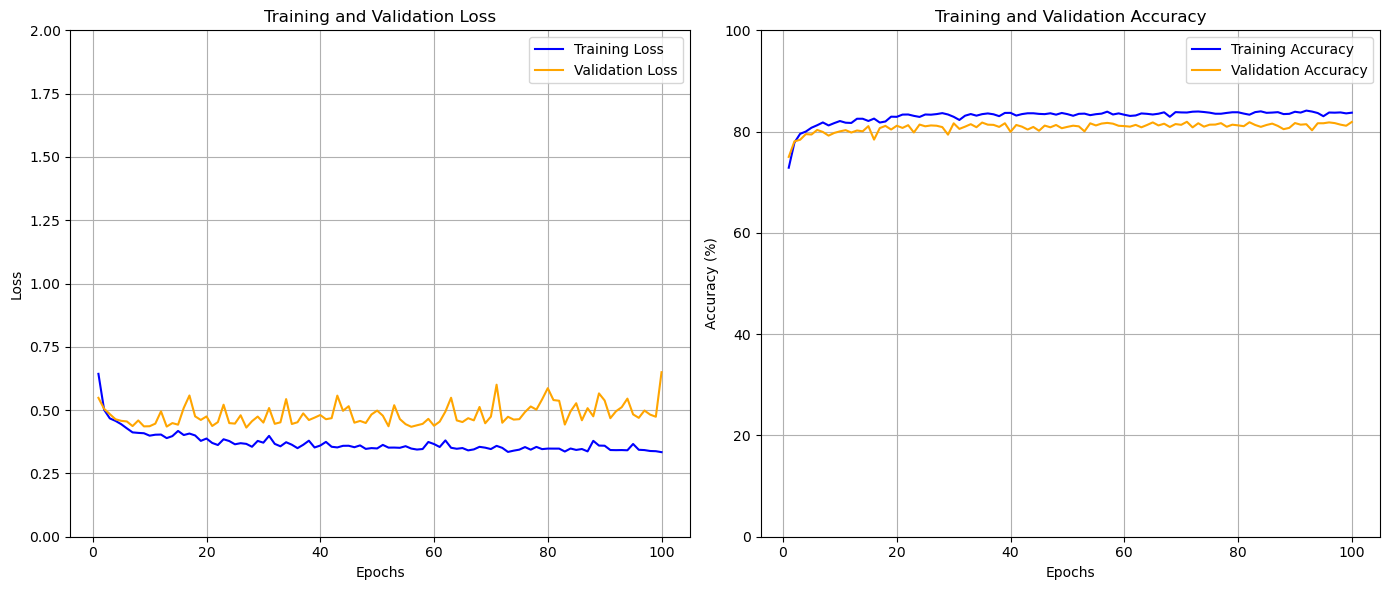

In [31]:
plot_metrics(metrics['train_losses'], metrics['val_losses'], metrics['train_accuracies'], metrics['val_accuracies'])

In [32]:
# Using the last model created
trained_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = trained_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metric
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='macro',  # Use 'macro' for multi-class
    zero_division=0.0
)
test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")

# test_auc_score = roc_auc_score(test_true_labels, test_predictions, multi_class='ovo')

# print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score on test set: 81.73 %
Precision: 0.5495
Recall: 0.5805
F1-Score: 0.5627

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.91      0.83      6251
           1       0.00      0.00      0.00       818
           2       0.88      0.83      0.86      6251

    accuracy                           0.82     13320
   macro avg       0.55      0.58      0.56     13320
weighted avg       0.77      0.82      0.79     13320


Confusion Matrix:
[[5676    0  575]
 [ 714    0  104]
 [1041    0 5210]]


/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [33]:
# Load the best model
device = get_device()
best_model = Classifier(input_size=X_train.shape[1]).to(device)
best_model.load_state_dict(torch.load('ranking.pth'))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        # probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metric
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='macro',  # Use 'macro' for multi-class
    zero_division=0.0
)
test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
# test_auc_score = roc_auc_score(test_true_labels, test_predictions)
# print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB
Accuracy Score on test set: 81.99 %
Precision: 0.5586
Recall: 0.5824
F1-Score: 0.5649

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      6251
           1       0.00      0.00      0.00       818
           2       0.74      0.95      0.83      6251

    accuracy                           0.82     13320
   macro avg       0.56      0.58      0.56     13320
weighted avg       0.79      0.82      0.80     13320


Confusion Matrix:
[[5013    0 1238]
 [  25    0  793]
 [ 343    0 5908]]


/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [41]:
import numpy as np

large_matrix = np.zeros((250*250, 40000), dtype=np.float64)
print(f"Matrix memory usage: {large_matrix.nbytes / (1024**3):.2f} GB")

Matrix memory usage: 18.63 GB
